# Binomial-Beta Model of the Marth-Fox Matchup

In [1]:
import pymc as pm
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from pymc.math import dot
import pytensor.tensor as pt

import math
import scipy.stats as sc
import sympy as sp

# Set random seed
seed = 6420
rng = np.random.default_rng(seed)

## Analytical Approach

We can find the exact posterior since the Beta prior can form a conjugate distribution with the posterior with respect to the Binomial likelihood. For simplicity (and to shorten execution time), we can find our posterior kernel to show that such a likelihood and prior result in a Beta posterior.

In [2]:
alpha, beta, theta = sp.symbols('alpha beta theta', real=True, positive=True)
x, n = sp.symbols('x n', integer=True, positive=True)

prior = (theta**(alpha - 1) * (1 - theta)**(beta - 1))
likelihood = theta**x * (1 - theta)**(n - x)

posterior = prior * likelihood
sp.simplify(posterior)


theta**(alpha + x - 1)*(1 - theta)**(beta + n - x - 1)

Prior: 6/4, Posterior Mean: 0.70
Prior: 5/5, Posterior Mean: 0.65
Prior: 4/6, Posterior Mean: 0.60


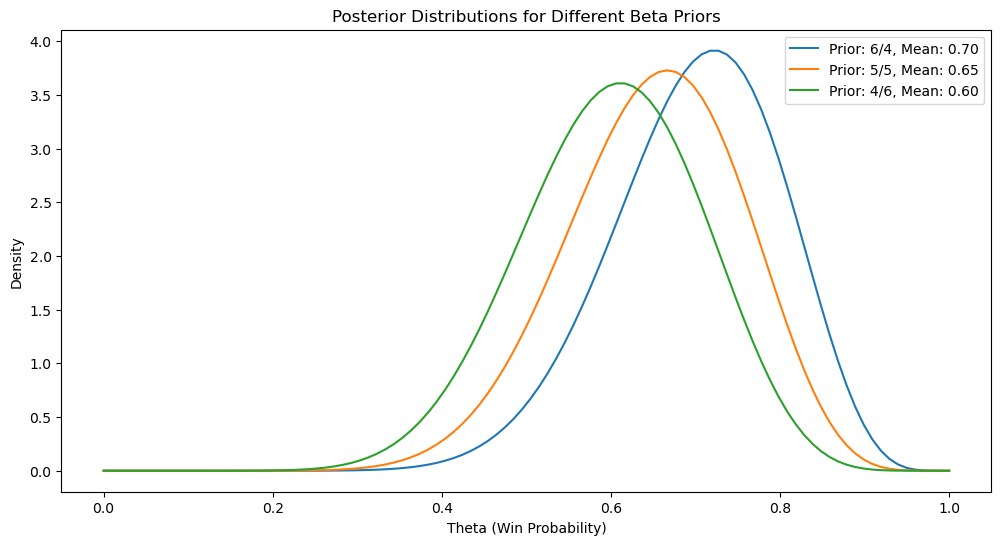

In [3]:
# Assume we have observed 8 wins out of 10 matches
x_obs = 8
n_obs = 10

# Assume we have three beta priors: 60/40, 50/50, and 40/60
priors = [(6, 4), (5, 5), (4, 6)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0, 1, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.show()

We can also try different strengths of beta priors, depending on how confident we are in a matchup spread. For example, let us try different beta priors where the expected matchup is 50/50 (i.e. alpha=beta)

Prior: 1/1, Posterior Mean: 0.75
Prior: 10/10, Posterior Mean: 0.60
Prior: 100/100, Posterior Mean: 0.51


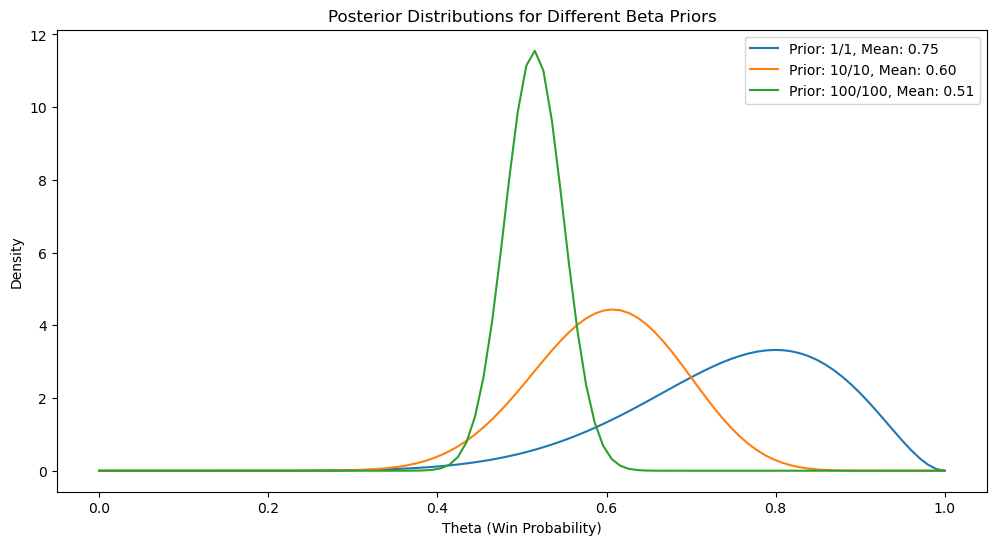

In [ ]:
# Assume we have observed 8 wins out of 10 matches
x_obs = 8
n_obs = 10

# Assume our priors vary in strength: 1/1 (non-informative), 10/10 (moderately informative), and 100/100 (strongly informative)
priors = [(1, 1), (10, 10), (100, 100)]

# Plot posterior distributions for each prior
theta_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 6))
for alpha_prior, beta_prior in priors:
    post_alpha = alpha_prior + x_obs
    post_beta = beta_prior + n_obs - x_obs
    post = sc.beta(a=post_alpha, b=post_beta)
    mean = post.mean()
    print(f"Prior: {alpha_prior}/{beta_prior}, Posterior Mean: {mean:.2f}")
    x = np.linspace(0, 1, 100)
    y = post.pdf(x)
    plt.plot(x, y, label=f'Prior: {alpha_prior}/{beta_prior}, Mean: {mean:.2f}')
plt.title('Posterior Distributions for Different Beta Priors')
plt.xlabel('Theta (Win Probability)')
plt.ylabel('Density')
plt.legend()
plt.show()